In [1]:
import os 
import pandas as pd 
import seaborn as sns

In [3]:
estudiantes = pd.read_csv("EjemploEstudiantes.csv", sep=";", decimal=",")
estudiantes.head()

,Unnamed: 0,Matematicas,Ciencias,Espanol,Historia,EdFisica
0,Lucia,7.0,6.5,9.2,8.6,8.0
1,Pedro,7.5,9.4,7.3,7.0,7.0
2,Ines,7.6,9.2,8.0,8.0,7.5
3,Luis,5.0,6.5,6.5,7.0,9.0
4,Andres,6.0,6.0,7.8,8.9,7.3


In [4]:
estudiantes = estudiantes.rename(columns={"Unnamed: 0": "nombre"})

nombres = estudiantes["nombre"]
datos_numericos = estudiantes.drop(columns=["nombre"])

In [7]:
from numpy import array 
from sklearn.decomposition import TruncatedSVD
A = estudiantes 
#Remover columna no numerica
A = A.drop(["nombre"], axis = 1)
A

,Matematicas,Ciencias,Espanol,Historia,EdFisica
0,7.0,6.5,9.2,8.6,8.0
1,7.5,9.4,7.3,7.0,7.0
2,7.6,9.2,8.0,8.0,7.5
3,5.0,6.5,6.5,7.0,9.0
4,6.0,6.0,7.8,8.9,7.3
5,7.8,9.6,7.7,8.0,6.5
6,6.3,6.4,8.2,9.0,7.2
7,7.9,9.7,7.5,8.0,6.0
8,6.0,6.0,6.5,5.5,8.7
9,6.8,7.2,8.7,9.0,7.0


In [8]:
from numpy import diag
from numpy import zeros 
from scipy.linalg import svd 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [9]:
U, s, VT = svd(A) #Obtencion de matrices cuyo producto arroja la matriz A
Sigma = zeros((A.shape[0], A.shape[1])) #Creacion de matriz de ceros de la misma dimension que A 
Sigma[:A.shape[1], :A.shape[1]] = diag(s)

In [10]:
print("Matriz U:")
print(U)

Matriz U:
[[-3.30904778e-01 -2.98442471e-01  1.95957496e-01 -5.49129984e-01
   3.41498230e-01  3.14150349e-02 -1.23395489e-01  1.44668847e-01
  -3.94701586e-01 -3.89792548e-01]
 [-3.20798129e-01  3.55909651e-01 -2.40201517e-01 -6.92729616e-02
   2.04368756e-01 -4.82498850e-01  2.12566116e-01 -5.29979923e-01
  -2.91960519e-01  1.48477689e-01]
 [-3.38871518e-01  2.14752307e-01 -1.01355072e-01  1.12970083e-02
   1.76844101e-01 -1.27934010e-01 -3.25968835e-01 -5.72499990e-02
   7.00049221e-01 -4.25915443e-01]
 [-2.86319969e-01 -3.47796853e-01 -4.56775340e-01  6.26123724e-01
   3.29136285e-01  7.19838459e-02 -5.36517108e-04  2.16809671e-01
  -1.85075729e-01 -4.01432467e-02]
 [-3.03747698e-01 -3.04664300e-01  2.89885414e-01  2.58403657e-01
  -5.09400304e-01 -1.58301296e-01 -4.86485858e-01 -3.39970765e-01
  -1.65040306e-01  8.72429330e-03]
 [-3.33011382e-01  3.96082489e-01  2.51606890e-02  5.94976208e-02
  -5.78210369e-02  8.06621727e-01  1.34546582e-02 -2.29782306e-01
  -1.43611096e-01 -2.14

In [11]:
print("Matriz Sigma:")
print(Sigma)

Matriz Sigma:
[[53.21335049  0.          0.          0.          0.        ]
 [ 0.          5.35631448  0.          0.          0.        ]
 [ 0.          0.          3.80560674  0.          0.        ]
 [ 0.          0.          0.          1.46904724  0.        ]
 [ 0.          0.          0.          0.          0.47799818]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]


In [12]:
print("Matriz VT")
print(VT)

Matriz VT
[[-0.40556463 -0.45759727 -0.46123811 -0.47103299 -0.43761787]
 [ 0.30388113  0.70497323 -0.20845983 -0.2165757  -0.56595801]
 [-0.00426062 -0.27229676  0.31573346  0.5963283  -0.6859601 ]
 [-0.56293162  0.34606734 -0.50555254  0.5444058   0.1066974 ]
 [-0.65288853  0.31576789  0.62332408 -0.28149203 -0.07909827]]


In [13]:
#Para reconstruir la matriz original 
B = U.dot(Sigma.dot(VT))
print(B)

[[7.  6.5 9.2 8.6 8. ]
 [7.5 9.4 7.3 7.  7. ]
 [7.6 9.2 8.  8.  7.5]
 [5.  6.5 6.5 7.  9. ]
 [6.  6.  7.8 8.9 7.3]
 [7.8 9.6 7.7 8.  6.5]
 [6.3 6.4 8.2 9.  7.2]
 [7.9 9.7 7.5 8.  6. ]
 [6.  6.  6.5 5.5 8.7]
 [6.8 7.2 8.7 9.  7. ]]


In [14]:
#Reduccion a dos dimensiones 
n_elements = 2

UReduced2 = U[:,:n_elements]
print("U reducida:")
print(UReduced2)

U reducida:
[[-0.33090478 -0.29844247]
 [-0.32079813  0.35590965]
 [-0.33887152  0.21475231]
 [-0.28631997 -0.34779685]
 [-0.3037477  -0.3046643 ]
 [-0.33301138  0.39608249]
 [-0.31300374 -0.24404278]
 [-0.328788    0.47553197]
 [-0.27389698 -0.26452216]
 [-0.32638301 -0.10871076]]


In [15]:
SigmaReduced2 = Sigma[:n_elements,:n_elements]
print("Matriz Sigma Reducida")
print(SigmaReduced2)

Matriz Sigma Reducida
[[53.21335049  0.        ]
 [ 0.          5.35631448]]


In [16]:
VTReduced2 = VT[:n_elements, :]
print("VT Reducida")
print(VTReduced2)

VT Reducida
[[-0.40556463 -0.45759727 -0.46123811 -0.47103299 -0.43761787]
 [ 0.30388113  0.70497323 -0.20845983 -0.2165757  -0.56595801]]


In [17]:
AReduced2 = UReduced2.dot(SigmaReduced2.dot(VTReduced2))
print("Matriz A Transformada:")
print(AReduced2)

Matriz A Transformada:
[[6.65563617 6.93068907 8.45496902 8.64041633 8.61053016]
 [7.50259774 9.15546106 7.47627701 7.62801112 6.39154032]
 [7.66288835 9.06253486 8.0774837  8.24477427 7.24032869]
 [5.61309793 5.65867129 7.41578628 7.58014066 7.72189396]
 [6.05941975 6.24591247 7.7953721  7.96693512 7.99698132]
 [7.83156613 9.60455223 7.73118336 7.88753689 6.55416982]
 [6.35785122 6.70021013 7.95486409 8.12861624 8.02875678]
 [7.86973795 9.80171752 7.53881312 7.68951159 6.21497236]
 [5.48053658 5.67061811 7.01789357 7.17215282 7.18015541]
 [6.86687283 7.53702066 8.13213661 8.30697925 7.93006916]]


In [18]:
T2 = UReduced2.dot(SigmaReduced2)
print("Matriz T(2 Dimensiones):")
print(T2)

Matriz T(2 Dimensiones):
[[-17.60855193  -1.59855173]
 [-17.07074326   1.90636402]
 [-18.03248887   1.15028089]
 [-15.23604486  -1.86290932]
 [-16.1634327   -1.6318778 ]
 [-17.7206514    2.12154237]
 [-16.65597775  -1.30716988]
 [-17.49591103   2.54709878]
 [-14.57497601  -1.41686385]
 [-17.36793336  -0.58228904]]


<function matplotlib.pyplot.show(close=None, block=None)>

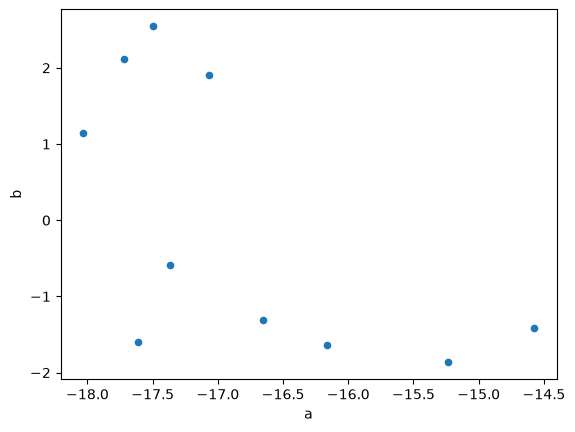

In [19]:
df = pd.DataFrame(T2, columns = ["a","b"])
df.plot(kind = "scatter", x = "a", y = "b")
plt.show

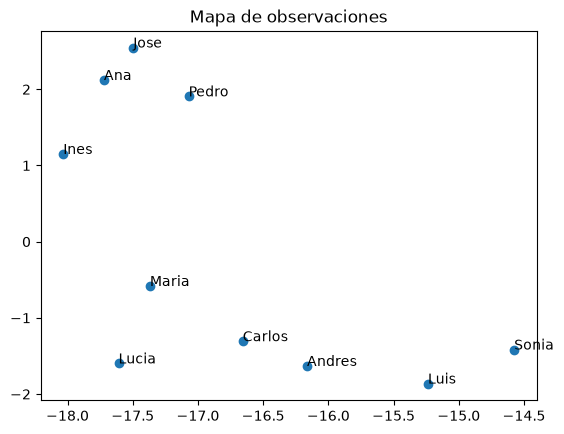

In [22]:
df = pd.DataFrame(T2, columns = ["a","b"])
x = df.iloc[:,0]
y = df.iloc[:,1]
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x,y)

for i, txt in enumerate(nombres):
    ax.annotate(txt, (x[i], y[i]))

In [23]:
#Reduccion a 3 dimensiones 
n_elements = 3

UReduced3 = U[:,:n_elements]

SigmaReduced3 = Sigma[:n_elements,:n_elements]

VTReduced3 = VT[:n_elements, :]

AReduced3 = UReduced3.dot(SigmaReduced3.dot(VTReduced3))
print("Matriz A Transformada:")
print(AReduced3)

Matriz A Transformada:
[[6.65245886 6.72762726 8.69042319 9.08512051 8.09898421]
 [7.50649243 9.40437093 7.1876611  7.08289996 7.01858503]
 [7.66453175 9.1675645  7.95569976 8.01475998 7.50491554]
 [5.6205042  6.13200674 6.8669445  6.54353881 8.91430342]
 [6.05471948 5.94551744 8.14368606 8.62479847 7.24023707]
 [7.83115817 9.57847935 7.76141538 7.94463634 6.48848799]
 [6.35253602 6.36051578 8.34874639 8.87254488 7.17301112]
 [7.86825556 9.7069775  7.64866605 7.89699168 5.97630674]
 [5.49031524 6.29557293 6.29324613 5.80350542 8.75451889]
 [6.86123771 7.17687926 8.54972766 9.09568679 7.02281405]]


In [24]:
print("UReduced3:", UReduced3.shape)
print("SigmaReduced3:", SigmaReduced3.shape)

T3 = UReduced3.dot(SigmaReduced3)
print("Matriz T(3 Dimensiones):")
print(T3)

UReduced3: (10, 3)
SigmaReduced3: (3, 3)
Matriz T(3 Dimensiones):
[[-17.60855193  -1.59855173   0.74573717]
 [-17.07074326   1.90636402  -0.91411251]
 [-18.03248887   1.15028089  -0.38571754]
 [-15.23604486  -1.86290932  -1.73830731]
 [-16.1634327   -1.6318778    1.10318989]
 [-17.7206514    2.12154237   0.09575169]
 [-16.65597775  -1.30716988   1.24751522]
 [-17.49591103   2.54709878   0.34792931]
 [-14.57497601  -1.41686385  -2.29512399]
 [-17.36793336  -0.58228904   1.32260625]]


In [25]:
from mpl_toolkits import mplot3d
%matplotlib inline

In [26]:
df3 = pd.DataFrame(T3, columns = ["a","b","c"])
df3

,a,b,c
0,-17.608552,-1.598552,0.745737
1,-17.070743,1.906364,-0.914113
2,-18.032489,1.150281,-0.385718
3,-15.236045,-1.862909,-1.738307
4,-16.163433,-1.631878,1.103190
5,-17.720651,2.121542,0.095752
6,-16.655978,-1.307170,1.247515
7,-17.495911,2.547099,0.347929
8,-14.574976,-1.416864,-2.295124
9,-17.367933,-0.582289,1.322606


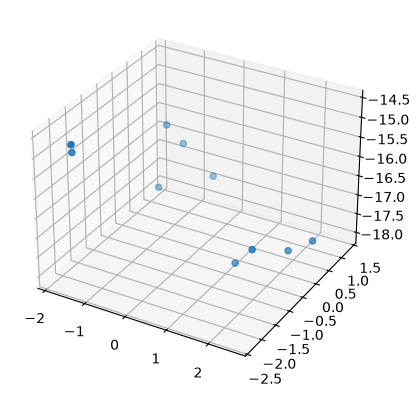

In [27]:
fig = plt.figure()
ax = plt.axes(projection = "3d")
xline = df3["b"]
yline = df3["c"]
zline = df3["a"]
ax.scatter3D(xline, yline, zline)

<Axes: >

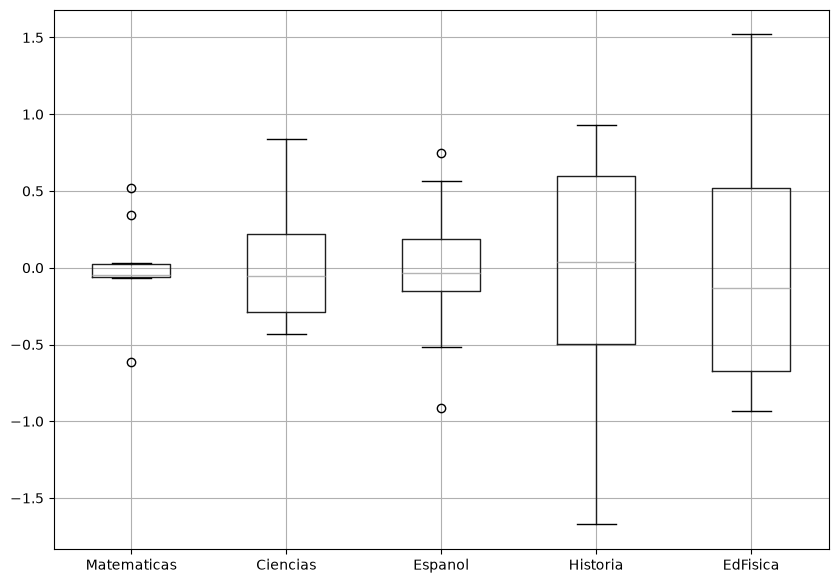

In [29]:
plt.figure(figsize = (10,7))
Error2 = B - AReduced2

dfError2 = pd.DataFrame(Error2, columns = ["Matematicas","Ciencias","Espanol","Historia","EdFisica"])
dfError2.boxplot()

In [30]:
print("Errores promedio por columna")
Error2.mean(axis = 0)

Errores promedio por columna


array([-2.04650684e-05,  1.32612606e-02, -1.94778869e-02, -2.45074289e-02,
        3.30602005e-02])

In [31]:
Error3 = B - AReduced3
print(Error3)

[[ 0.34754114 -0.22762726  0.50957681 -0.48512051 -0.09898421]
 [-0.00649243 -0.00437093  0.1123389  -0.08289996 -0.01858503]
 [-0.06453175  0.0324355   0.04430024 -0.01475998 -0.00491554]
 [-0.6205042   0.36799326 -0.3669445   0.45646119  0.08569658]
 [-0.05471948  0.05448256 -0.34368606  0.27520153  0.05976293]
 [-0.03115817  0.02152065 -0.06141538  0.05536366  0.01151201]
 [-0.05253602  0.03948422 -0.14874639  0.12745512  0.02698888]
 [ 0.03174444 -0.0069775  -0.14866605  0.10300832  0.02369326]
 [ 0.50968476 -0.29557293  0.20675387 -0.30350542 -0.05451889]
 [-0.06123771  0.02312074  0.15027234 -0.09568679 -0.02281405]]


<Axes: >

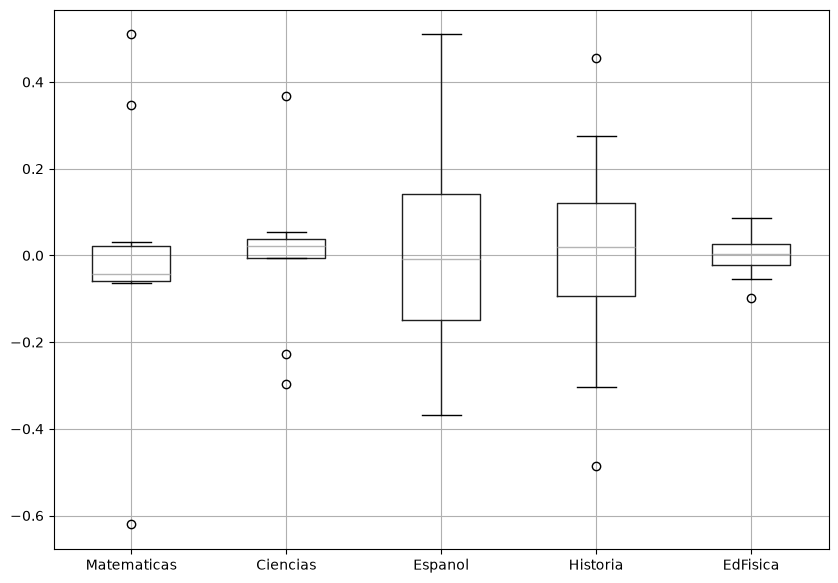

In [32]:
plt.figure(figsize = (10,7))
dfError3 = pd.DataFrame(Error3, columns = ["Matematicas","Ciencias","Espanol","Historia","EdFisica"])
dfError3.boxplot()

In [33]:
print("Errores promedio por columna")
Error3.mean(axis = 0)

Errores promedio por columna


array([-0.00022094,  0.00044883, -0.00462162,  0.00355172,  0.00078359])

In [ ]:
##La separación con 3 dimensiones es más precisa que con 2 dimensiones, porque con 3 dimensioes se puede ver mejor la separacion, que con 2 dimensiones
##Con el analisis de componentes principales donde vimos los clusters, llegamos al mismo resultado, por lo que los resultados no difieren tanto.